# Vision Transformer (ViT-B/16) with Weighted BCE and Stronger Regularization

- Backbone: pretrained `vit_b_16` from `torchvision`
- Objective: binary melanoma detection with class weighting

**Objective** <br/>
Improve the original weighted ViT training setup by reducing overfitting pressure and making validation performance more stable.

**What changed in this version** <br/>
- Switch optimizer from `Adam` to `AdamW`
- Add `weight_decay` for L2 regularization
- Lower the learning rate
- Add `ReduceLROnPlateau` based on validation F2
- Add early stopping based on validation F2
- Keep the best checkpoint and visualize correct vs wrong test predictions

**Hypothesis** <br/>
A more regularized optimizer and tighter training control should reduce unstable validation behavior while preserving strong melanoma recall.


### 1. Import libraries
Import the model, training utilities, metrics, plotting dependencies, and helpers for checkpoint tracking.


In [1]:
import sys
import os
import copy
sys.path.append(os.path.abspath("../.."))

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.vit import get_vit
from src.training.trainer import train_one_epoch, validate_one_epoch

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)


### 2. Use MPS

In [2]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")


MPS available: True
Using device: mps


### 3. Split Dataset and Configure Weighted Loss
Load the train, validation, and test splits, compute class weighting from the training set, and initialize the pretrained ViT model with a more regularized optimizer.


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_melanoma = (train_df["label"] == 0).sum()
num_nevus = (train_df["label"] == 1).sum()

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight)

model = get_vit(num_classes=1, freeze_backbone=False, dropout=0.1).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)


pos_weight: tensor([6.0244], device='mps:0')


### 4. Train Model
Train the ViT while tracking the best validation F2, reducing the learning rate on plateaus, and stopping early once validation performance stops improving.


In [4]:
model_save_path = os.path.abspath("../../models/vit_weighted_v2.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

num_epochs = 15
early_stopping_patience = 4

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []
learning_rates = []

best_val_f2 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_state = None

for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]["lr"]

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_metrics["f2"])

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])
    train_f2s.append(train_metrics["f2"])
    val_f2s.append(val_metrics["f2"])
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics["f2"] > best_val_f2:
        best_val_f2 = val_metrics["f2"]
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, model_save_path)
        print(f"Saved best model at epoch {best_epoch}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

print(f"Best validation F2: {best_val_f2:.4f} at epoch {best_epoch}")

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch [1/15] | LR: 0.000050 | Train Loss: 0.7030, Train Acc: 0.7814, Train F2: 0.6725 | Val Loss: 0.6960, Val Acc: 0.6684, Val F2: 0.6672
Saved best model at epoch 1


Epoch [2/15] | LR: 0.000050 | Train Loss: 0.5648, Train Acc: 0.8209, Train F2: 0.7368 | Val Loss: 0.6053, Val Acc: 0.8031, Val F2: 0.7094
Saved best model at epoch 2


Epoch [3/15] | LR: 0.000050 | Train Loss: 0.4909, Train Acc: 0.8554, Train F2: 0.7653 | Val Loss: 0.5963, Val Acc: 0.8321, Val F2: 0.7121
Saved best model at epoch 3


Epoch [4/15] | LR: 0.000050 | Train Loss: 0.4007, Train Acc: 0.8905, Train F2: 0.8188 | Val Loss: 0.5845, Val Acc: 0.8858, Val F2: 0.7536
Saved best model at epoch 4


Epoch [5/15] | LR: 0.000050 | Train Loss: 0.3626, Train Acc: 0.8975, Train F2: 0.8306 | Val Loss: 0.5258, Val Acc: 0.8474, Val F2: 0.7582
Saved best model at epoch 5


Epoch [6/15] | LR: 0.000050 | Train Loss: 0.2808, Train Acc: 0.9269, Train F2: 0.8812 | Val Loss: 0.9348, Val Acc: 0.9020, Val F2: 0.6967


Epoch [7/15] | LR: 0.000050 | Train Loss: 0.2586, Train Acc: 0.9393, Train F2: 0.8980 | Val Loss: 0.8002, Val Acc: 0.8968, Val F2: 0.7330


Epoch [8/15] | LR: 0.000050 | Train Loss: 0.2304, Train Acc: 0.9423, Train F2: 0.9030 | Val Loss: 0.8781, Val Acc: 0.9139, Val F2: 0.7168


Epoch [9/15] | LR: 0.000025 | Train Loss: 0.0994, Train Acc: 0.9746, Train F2: 0.9564 | Val Loss: 0.8594, Val Acc: 0.9165, Val F2: 0.7278
Early stopping triggered at epoch 9
Best validation F2: 0.7582 at epoch 5


### 5. Plot Training Curves
Plot loss, accuracy, F2, and learning rate to inspect whether the regularized setup stabilizes validation behavior.


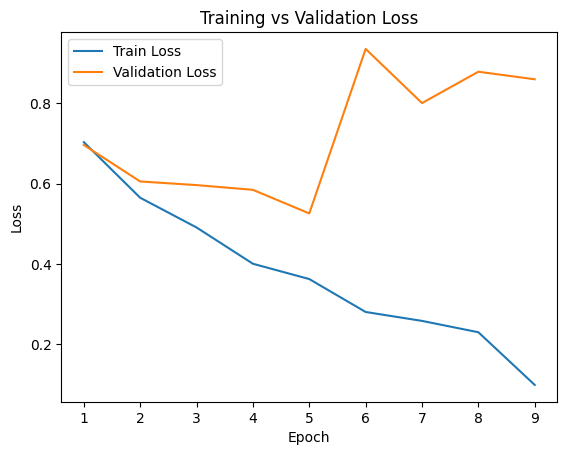

In [5]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


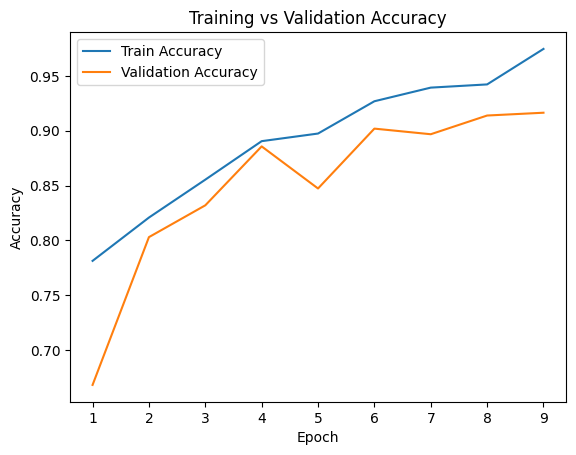

In [6]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


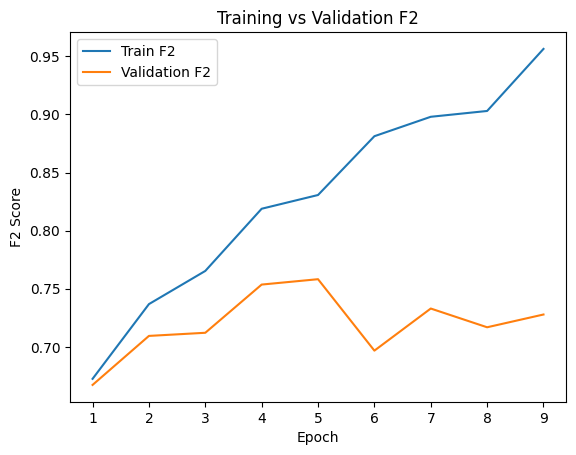

In [7]:
plt.figure()
plt.plot(epochs, train_f2s, label="Train F2")
plt.plot(epochs, val_f2s, label="Validation F2")
plt.xlabel("Epoch")
plt.ylabel("F2 Score")
plt.title("Training vs Validation F2")
plt.legend()
plt.show()


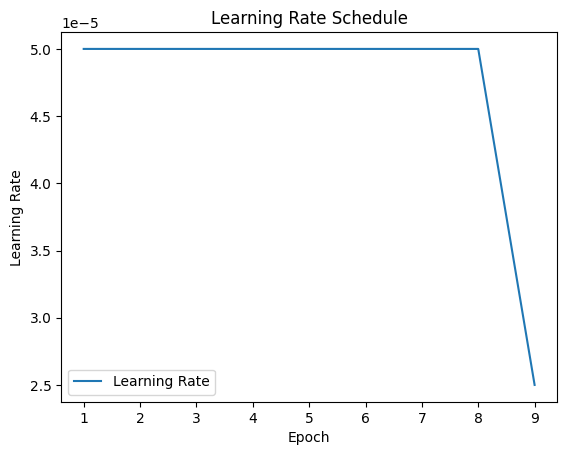

In [8]:
plt.figure()
plt.plot(epochs, learning_rates, label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()


### 6. Tune Threshold on Validation Set
Sweep decision thresholds on the validation set and keep the threshold with the best F2 score before evaluating on the test set.


In [9]:
model = get_vit(num_classes=1, freeze_backbone=False, dropout=0.1).to(device)
model.load_state_dict(torch.load(model_save_path, map_location="cpu"))
model.to(device)
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.05, 0.95, 0.05)
best_threshold = 0.5
best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    f2 = fbeta_score(val_labels, preds, beta=2)

    print(
        f"Threshold={threshold:.2f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision_score(val_labels, preds, zero_division=0):.4f} | "
        f"Recall={recall_score(val_labels, preds, zero_division=0):.4f} | "
        f"Balanced Acc={balanced_accuracy_score(val_labels, preds):.4f}"
    )

    if f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

print(f"Best threshold on validation set: {best_threshold:.2f}")


Threshold=0.05 | F2=0.6768 | Precision=0.2995 | Recall=0.9880 | Balanced Acc=0.8022
Threshold=0.10 | F2=0.7021 | Precision=0.3280 | Recall=0.9820 | Balanced Acc=0.8240
Threshold=0.15 | F2=0.7030 | Precision=0.3404 | Recall=0.9581 | Balanced Acc=0.8250
Threshold=0.20 | F2=0.7181 | Precision=0.3587 | Recall=0.9581 | Balanced Acc=0.8369
Threshold=0.25 | F2=0.7281 | Precision=0.3789 | Recall=0.9461 | Balanced Acc=0.8443
Threshold=0.30 | F2=0.7385 | Precision=0.3975 | Recall=0.9401 | Balanced Acc=0.8518
Threshold=0.35 | F2=0.7436 | Precision=0.4094 | Recall=0.9341 | Balanced Acc=0.8552
Threshold=0.40 | F2=0.7527 | Precision=0.4338 | Recall=0.9222 | Balanced Acc=0.8612
Threshold=0.45 | F2=0.7472 | Precision=0.4529 | Recall=0.8922 | Balanced Acc=0.8566
Threshold=0.50 | F2=0.7582 | Precision=0.4805 | Recall=0.8862 | Balanced Acc=0.8636
Threshold=0.55 | F2=0.7680 | Precision=0.5087 | Recall=0.8802 | Balanced Acc=0.8695
Threshold=0.60 | F2=0.7660 | Precision=0.5294 | Recall=0.8623 | Balanced Acc

### 7. Evaluate on Test Set
Run the best validation threshold on the test split and inspect the confusion matrix and classification report.


In [10]:
model = get_vit(num_classes=1, freeze_backbone=False, dropout=0.1).to(device)
model.load_state_dict(torch.load(model_save_path, map_location="cpu"))
model.to(device)
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))


Confusion Matrix:
[[864 142]
 [ 14 153]]

              precision    recall  f1-score   support

           0     0.9841    0.8588    0.9172      1006
           1     0.5186    0.9162    0.6623       167

    accuracy                         0.8670      1173
   macro avg     0.7513    0.8875    0.7898      1173
weighted avg     0.9178    0.8670    0.8809      1173



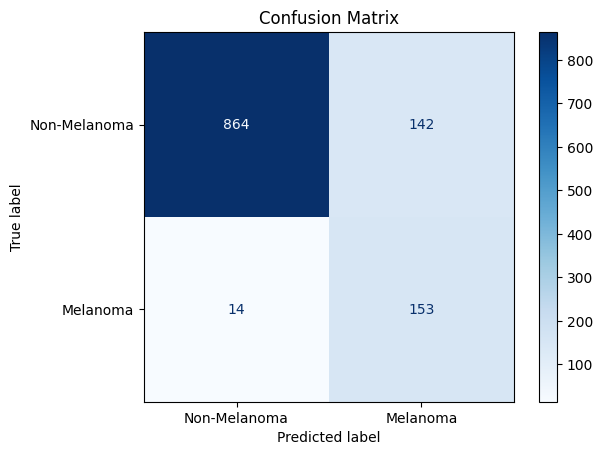

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


### 8. Visualize Correct and Wrong Test Predictions
Display example test images in 3x3 grids for both correctly classified and wrongly classified samples.


Collected 9 correct predictions and 9 wrong predictions.


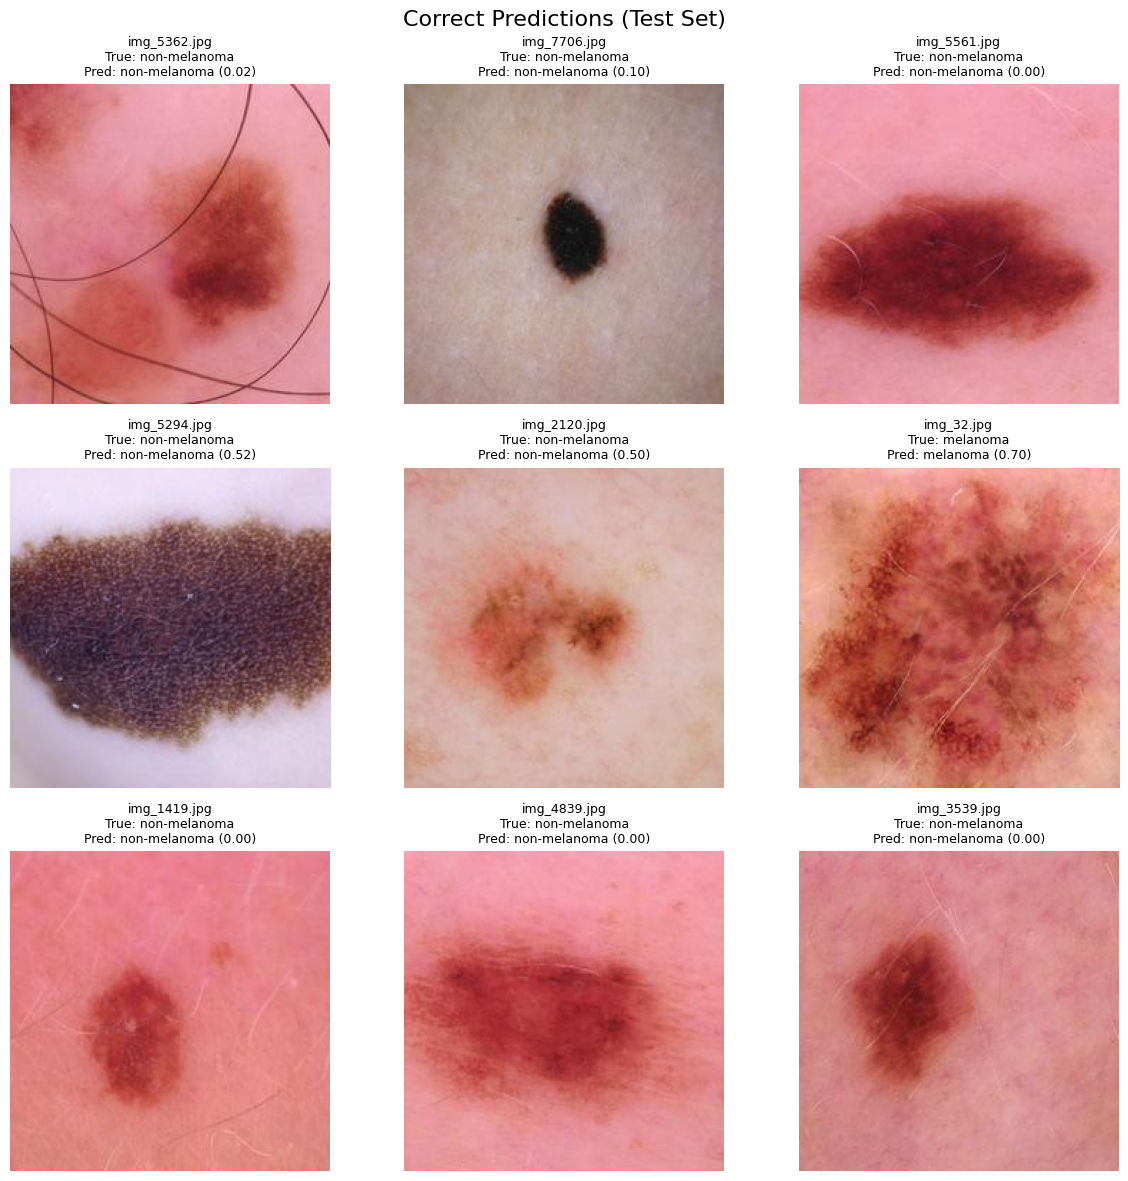

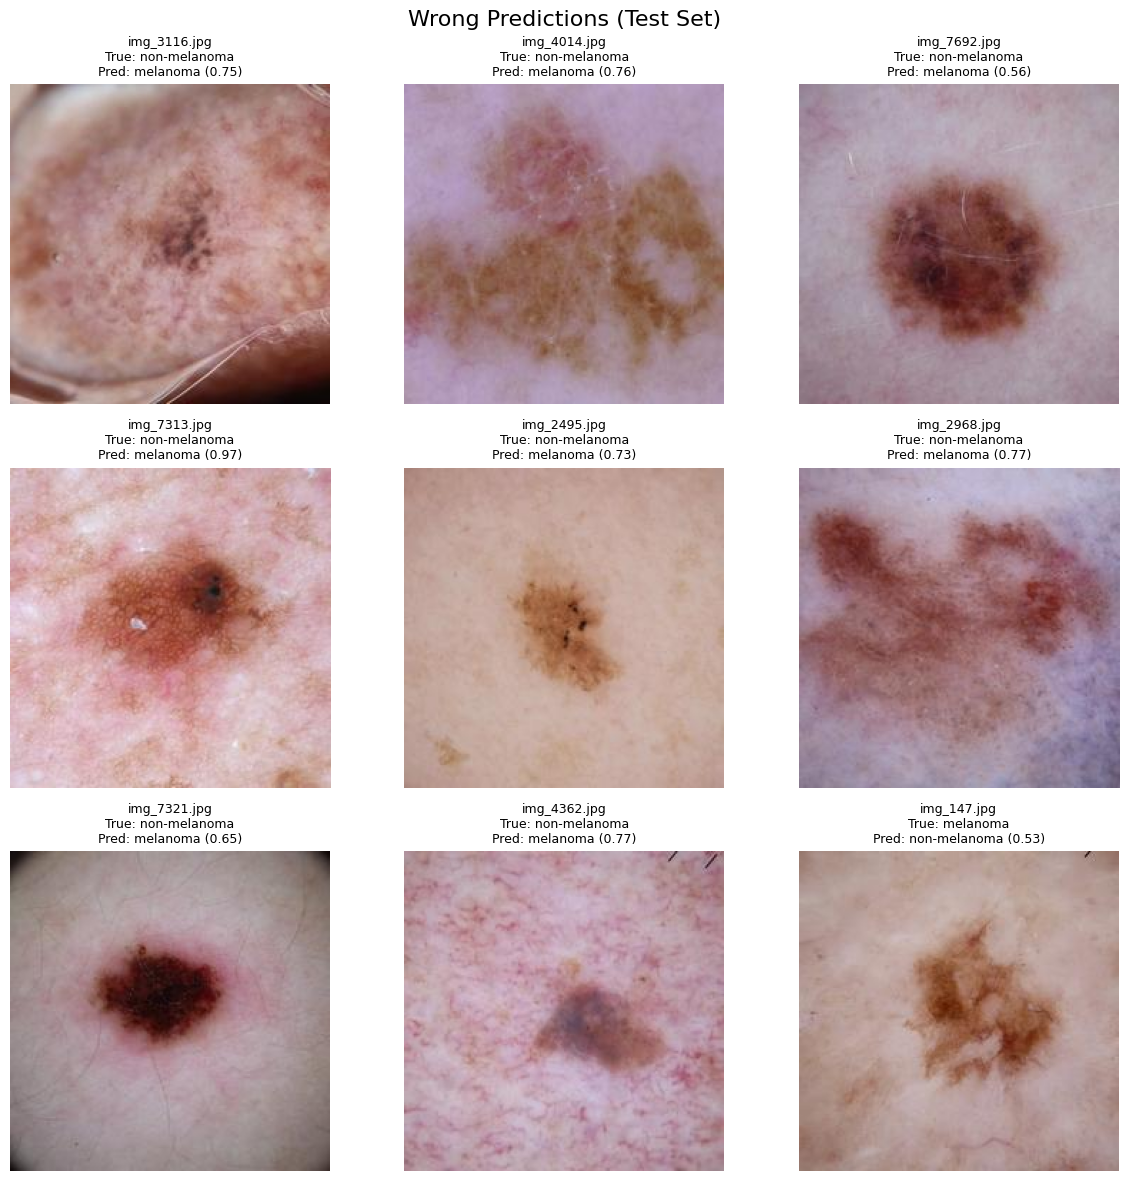

In [12]:
label_names = {0: "non-melanoma", 1: "melanoma"}
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_image(image_tensor):
    image = image_tensor.detach().cpu() * imagenet_std + imagenet_mean
    image = image.permute(1, 2, 0).numpy()
    return np.clip(image, 0, 1)

correct_examples = []
wrong_examples = []
global_idx = 0

test_metadata = test_loader.dataset.data.reset_index(drop=True)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1).cpu()
        preds = (probs >= threshold).long()

        for i in range(len(labels)):
            example = {
                "image": images[i],
                "true_label": int(labels[i].item()),
                "pred_label": int(preds[i].item()),
                "probability": float(probs[i].item()),
                "image_id": test_metadata.iloc[global_idx]["image_id"],
            }

            if example["true_label"] == example["pred_label"]:
                if len(correct_examples) < 9:
                    correct_examples.append(example)
            else:
                if len(wrong_examples) < 9:
                    wrong_examples.append(example)

            global_idx += 1

        if len(correct_examples) >= 9 and len(wrong_examples) >= 9:
            break


def plot_examples(examples, title):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    for ax, example in zip(axes, examples):
        ax.imshow(denormalize_image(example["image"]))
        ax.set_title(
            f"{example['image_id']}\n"
            f"True: {label_names[example['true_label']]}\n"
            f"Pred: {label_names[example['pred_label']]} ({example['probability']:.2f})",
            fontsize=9,
        )
        ax.axis("off")

    for ax in axes[len(examples):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print(f"Collected {len(correct_examples)} correct predictions and {len(wrong_examples)} wrong predictions.")
plot_examples(correct_examples, "Correct Predictions (Test Set)")
plot_examples(wrong_examples, "Wrong Predictions (Test Set)")


## What Was Added and Edited

This notebook updates the original ViT experiment in four main ways:

- Replaced `Adam` with `AdamW` to use decoupled weight decay.
- Added `weight_decay=1e-4` as L2 regularization to reduce overfitting pressure.
- Lowered the learning rate to `5e-5` for more stable ViT optimization.
- Added `ReduceLROnPlateau` so the learning rate shrinks when validation F2 stops improving.
- Added early stopping with patience `4` to avoid training too far past the best validation epoch.
- Added a learning-rate plot so scheduler behavior is visible.
- Kept best-model checkpointing based on validation F2.
- Added 3x3 test-image grids showing correctly classified and wrongly classified examples, including the original label and predicted label.

Expected effect:
The goal is to make validation behavior less noisy, reduce the train-vs-validation gap, and keep the model selection aligned with melanoma-sensitive F2 performance.

## Summary

- The model is overfitting much more than before
- I can confirm that the model is too large for this simple dataset
- Using a simple model would be sufficient
